In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

## 顧客の行動Pattern の類似度を計算しよう
- 特微Vector: 顧客の行動Pattern などの評価したい対象を数値化したもの
- 類似度: 特微Vector の違いを計算して得られる似ている度合い

#### Clustering
同じような特微Vector を持つものを分類すること

##### 分類
すでに何らかの方法で分類がなされているものに対して、原因を分析し、新たな対象がどの分類になされるかを予測すること

#### 回帰
特微Vector が時系列であった場合に、その時系列Pattern の傾向を予測すること

これらの機会学習の根幹となる **「特微Vector」** を定義し、その **「類似度」** を計算する

In [3]:
# Data(２年間の宿泊者) を読み込む
df_info = pd.read_csv('MathProgramming/Chapter2/accomodation_info.csv', index_col=0, parse_dates=[0])
df_info

,顧客ID,宿泊者名,プラン,金額
日時,,,,
2018-11-01 00:02:21,110034,若松 花子,B,19000
2018-11-01 00:03:10,112804,津田 美加子,D,20000
2018-11-01 00:06:19,110275,吉本 美加子,D,20000
2018-11-01 00:08:41,110169,坂本 直人,B,19000
2018-11-01 00:12:22,111504,青山 零,A,15000
...,...,...,...,...
2020-10-31 23:38:51,110049,吉本 篤司,A,3000
2020-10-31 23:42:12,110127,喜嶋 浩,A,3000
2020-10-31 23:47:24,115464,藤本 明美,D,8000


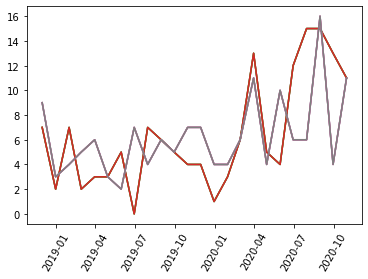

In [4]:
# 特微Vector（毎月の利用回数{宿泊回数}） を可視化する

# index の抽出
x_0 = df_info.resample('M').count()
x_0 = x_0.drop(x_0.columns.values, axis=1)

# 順位の設定
i_rank = 1
j_rank = 2

# 顧客ID の抽出
i_id = df_info['顧客ID'].value_counts().index[i_rank]
j_id = df_info['顧客ID'].value_counts().index[j_rank]

# 月毎の利用回数を特微量として抽出
x_i = df_info[df_info['顧客ID'] == i_id].resample('M').count()
x_j = df_info[df_info['顧客ID'] == j_id].resample('M').count()

# 欠損値があった場合の穴埋め
x_i = pd.concat([x_0, x_i], axis=1).fillna(0)
x_j = pd.concat([x_0, x_j], axis=1).fillna(0)

# 描画
plt.plot(x_i)
plt.plot(x_j)
plt.xticks(rotation=60)
plt.show()

In [5]:
# 類似度を計算する
# 類似度: 特微Vector 同士の距離を計算したうえで次元数で割ったものとし、０に近いほど類似性が近いと考える。

# 特微Vector の差を計算
dx = x_i.iloc[:, 0].values - x_j.iloc[:, 0].values

# Vector norm（距離）を計算
n = np.linalg.norm(dx)

# 次元による正規化
num_dim = x_i.shape[0]
d = n / num_dim
print('類似度:', d)

類似度: 0.798218502527834


## 類似度と機械学習との関係を知ろう

#### 教師あり学習
すでに分類 or 予測する方法が決まっている **「分類**と **「回帰」**

#### 教師なし学習
どのように分類するか自体を決める方法

### 機械学習を使った Data分析の Process
1. 特微Vector の定義（評価したい対象を数値化）し、必要に応じて可視化する。
2. 特微Vector の全体像を把握するために、**「次元削除」** を行ない多次元の特微Vector を２次元に表現して可視化する。
3. 可視化されたいくつかの Sample を **「Clustering」** することで行動Pattern を分類する。
4. Clustering によって分類された原因を分析したり、その原因から新たな Sample がどのよう分類されるべきかを予測するため **「分類」** を行なう
5. 合わせて時系列Pattern があれば、今後の動向の予測を **「回帰」** によって行なう。

## 大口顧客の類似性を主成分分析によって確認しよう

#### 主成分分析
- 「良い」次元を選ぶために伝統的に用いらている方法
- 何次元かで表現された Sample群を Sample の「ばらつき」が最も大きな「平面」で表現する

※多次元の中からある２つの次元を軸として選択した場合に選んだ次元が「良い」次元であれば二次元での可視化は見やすいものになるが、選択した次元がどの Sample をとっても０だった場合、すべての Sample の違いがわらない、ということになりかねたい為に生み出された。

In [6]:
# 特微Vector を抽出する

# index の調整
x_0 = df_info.resample('M').count()
x_0 = x_0.drop(x_0.columns.values, axis=1)

# 配列を準備
list_vector = []

# 人数の限定 ※上位100名までの宿泊者（顧客）を対象にする
num = 100
for i_rank in range(num):
    # 顧客ID の抽出
    i_id = df_info['顧客ID'].value_counts().index[i_rank]
    # 月毎の利用回数を特微量として抽出
    x_i = df_info[df_info['顧客ID'] == i_id].resample('M').count()
    # 欠損値があった場合の穴埋め
    x_i = pd.concat([x_0, x_i], axis=1).fillna(0)
    # 特微量Vector として追加
    list_vector.append(x_i.iloc[:, 0].values.tolist())

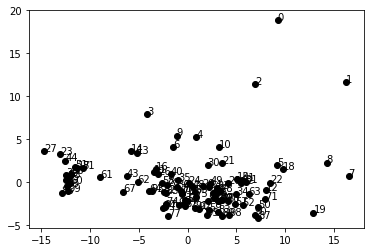

In [8]:
# 主成分分析を行なう

# 特微Vector を変換
features = np.array(list_vector)

# 主成分分析を実施 ※抽出した特微Vector のばらつきを最大にする
pca = PCA()
pca.fit(features)

# 特微Vector を主成分に変換
transformed = pca.fit_transform(features)

# 可視化
for i in range(len(transformed)):
    plt.scatter(transformed[i, 0], transformed[i, 1], color='k')
    plt.text(transformed[i, 0], transformed[i, 1], str(i))
plt.show()

主成分分析の結果として
- 真ん中の株に大きな塊
- 左側に小さな塊

が見られることがわかる。